<a href="https://colab.research.google.com/github/Najma-1437/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

In [ ]:
df.head() #test

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [ ]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 5268
Number of columns: 13


In [ ]:
#Last 75 rows, opposite of df.head()
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
df.isnull().sum()
#Determine the number of missing values in each column

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


In [ ]:
#For Time, 2,219 records are missing, we can't drop all this values or the mode and mean since we would be manufacturing a time so we decided to leave it at unknown.
df["Time"].fillna("Unknown")
#For Location, we could leave it at unknown or drop the records if the analysis specifically requires geographical information, we choose unknown.
df["Location"].fillna("Unknown")
#For Operator, for accounatbility purposes, we can't just assign the most common operator so we also assign unknown.
df["Operator"].fillna("Unknown")
#For Flights, 4199 missing and it is essentially an identifier, so we can't use mode because that would assign unrelated flights the same flight number so label unknown
df["Flight #"].fillna("Unknown")
#For Route, we can't use the most common route and potentially create a fake journey and deleting them would lead to a huge data loss. So also leaving as unknown.
df["Route"].fillna("Unknown")
#For Type, 27 are missing, we also decided to label unknown beacuse the type cannot be reliably inferred from the rest of the dataset.
df["Type"].fillna("Unknown")
#For registration, it is also an aircraft identifier so also left unknown
df["Registration"].fillna("Unknown")
#Also unknown since it is an identifier.
df["cn/In"].fillna("Unknown")
#For aboard, it has relatively few missing values so median is preferred here rather than mean because of passenger count difference in terms of aircraft capacity
df["Aboard"].fillna(df["Aboard"].median())
#For fatalities, only 12 values are missing, we can drop them from analyses requiring fatalities.
df.dropna(subset=["Fatalities"])
#For ground, the deaths on ground,we decided to leave as missing.
#For Summary, its text info that can't be statistically imputed so leaving as unknown.
df["Summary"].fillna("No summary available")











,Summary
0,"During a demonstration flight, a U.S. Army fly..."
1,First U.S. dirigible Akron exploded just offsh...
2,The first fatal airplane accident in Canada oc...
3,The airship flew into a thunderstorm and encou...
4,Hydrogen gas which was being vented was sucked...
...,...
5263,"While on approach, the military transport cras..."
5264,The cargo plane crashed while on approach to I...
5265,The Airbus went missing over the AtlantiOcean ...
5266,The air ambulance crashed into hills while att...


In [ ]:
fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]].copy()
fatality_locations.head() # to check if it worked, displaying the first 5 rows

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
#Getting the date of the highest number of recorded fatalities
max_index = fatality_locations["Fatalities"].idxmax()
#retrieving that row
fatality_locations.loc[max_index]
# getting only the date
fatality_locations.loc[max_index, "Date"]

'03/27/1977'

In [ ]:
#A crash with no fatalities, fatalities =0
fatality_locations["Fatalities"] == 0

no_fatalities = fatality_locations[
    fatality_locations["Fatalities"] == 0
]
no_fatalities # display
len(no_fatalities) #Count the records


58

In [ ]:
fatality_locations[["Region", "State/Country"]] = (
    fatality_locations["Location"].str.rsplit(",", n=1, expand=True)
) #Splitting the text whenever a comma is encountered and starting from the right.
fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [ ]:
top_100 = fatality_locations.sort_values(
    by="Fatalities",
    ascending=False
).head(100)
top_100

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


In [ ]:
#grouping by country/state
fatalities_by_country = (
    fatality_locations
    .groupby('State/Country')['Fatalities']
    .sum()
)
#Sorting
top_25 = fatalities_by_country.sort_values(
    ascending=False
).head(25) #take the top 25
top_25 #display

,Fatalities
State/Country,
Russia,6627.0
Brazil,3186.0
Colombia,2890.0
USSR,2831.0
France,2734.0
India,2603.0
China,2189.0
Japan,2050.0
Indonesia,1966.0


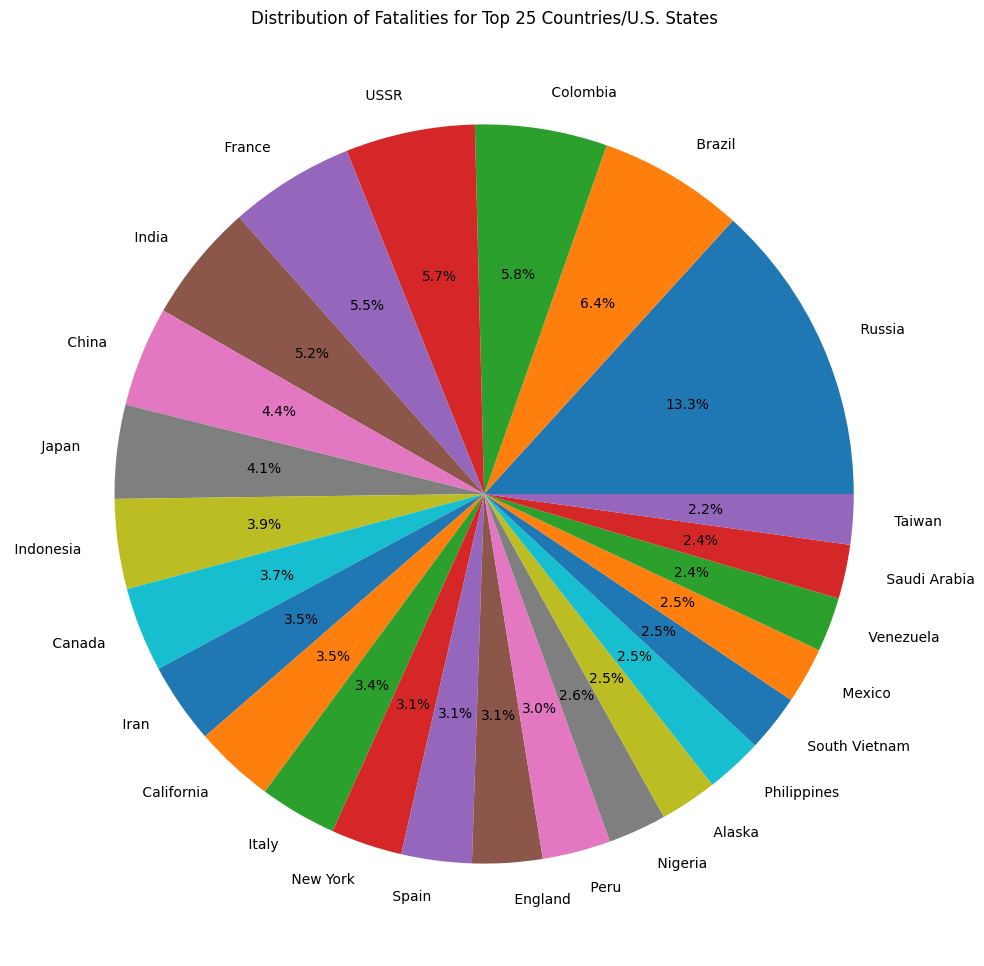

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))

top_25.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribution of Fatalities for Top 25 Countries/U.S. States')
plt.ylabel('')

plt.show()

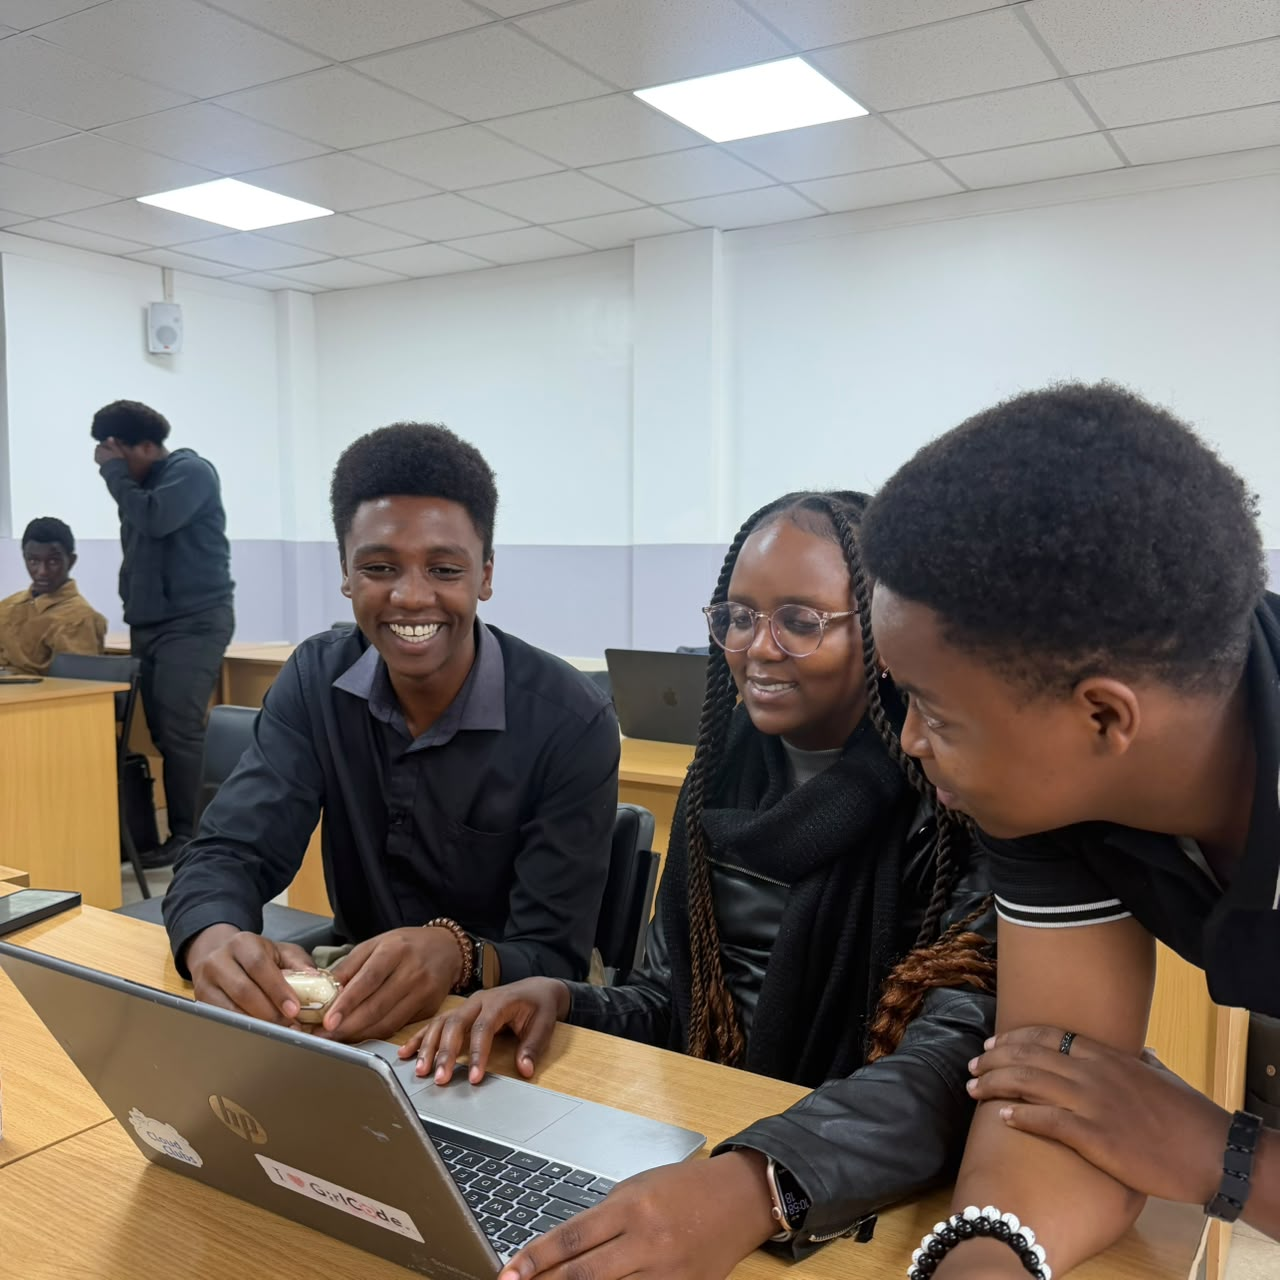

In [3]:
## Group photo evidence
from IPython.display import Image, display

display(Image(filename='Group photo.jpeg', width=700))